# Stock Price Prediction - Neural Networks

Multi-model comparison (LSTM, CNN, Transformer)

**Features Used:**
- Close price sequences (60 days)
- Momentum (percentage change)
- Company embeddings (bank-specific patterns)

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.9.0+cu126
Device: cuda


## 1. Data Loading and Preparation

In [2]:
# Load combined dataset
data = pd.read_csv("combined_banks_dataset.csv")
data['published_date'] = pd.to_datetime(data['published_date'])
data = data.sort_values(['company_id', 'published_date']).reset_index(drop=True)

print(f"Dataset shape: {data.shape}")
print(f"Number of banks: {data['company_id'].nunique()}")
print(f"Date range: {data['published_date'].min()} to {data['published_date'].max()}")
print(f"\nBanks: {sorted(data['company_id'].unique())}")

Dataset shape: (53063, 10)
Number of banks: 17
Date range: 2009-06-25 00:00:00 to 2025-12-29 00:00:00

Banks: ['ADBL', 'CZBIL', 'EBL', 'GBIME', 'HBL', 'KBL', 'MBL', 'NABIL', 'NBL', 'NICA', 'NMB', 'PCBL', 'PRVU', 'SANIMA', 'SBI', 'SBL', 'SCB']


In [3]:
# Create company-to-ID mapping for embedding layer
company_to_id = {company: idx for idx, company in enumerate(data['company_id'].unique())}
num_companies = len(company_to_id)
print(f"Company ID mapping: {company_to_id}")

Company ID mapping: {'ADBL': 0, 'CZBIL': 1, 'EBL': 2, 'GBIME': 3, 'HBL': 4, 'KBL': 5, 'MBL': 6, 'NABIL': 7, 'NBL': 8, 'NICA': 9, 'NMB': 10, 'PCBL': 11, 'PRVU': 12, 'SANIMA': 13, 'SBI': 14, 'SBL': 15, 'SCB': 16}


## 2. Sequence Creation

Create sequences per company to avoid data leakage between different banks.
Each sequence contains 60 timesteps with 2 features: close price and momentum.

In [4]:
def create_sequences(data, seq_length, company_mapping):
    """
    Create sequences for each company separately to prevent mixing data across banks.

    Returns:
        X: Feature sequences (close, momentum)
        y: Target values (next day close price)
        company_ids: Numeric company IDs for embedding
        dates: Corresponding dates
    """
    X, y, company_ids, dates = [], [], [], []

    # Fill NaN values in per_change
    data['per_change'] = data['per_change'].fillna(0)

    for company in data['company_id'].unique():
        company_data = data[data['company_id'] == company].sort_values('published_date')

        # Extract features
        close = company_data['close'].values
        momentum = company_data['per_change'].values
        dates_arr = company_data['published_date'].values

        # Create sequences within this company only
        for i in range(seq_length, len(close)):
            features = np.column_stack([
                close[i-seq_length:i],
                momentum[i-seq_length:i]
            ])

            X.append(features)
            y.append(close[i])
            company_ids.append(company_mapping[company])
            dates.append(dates_arr[i])

    return np.array(X), np.array(y), np.array(company_ids), np.array(dates)

SEQ_LENGTH = 60

X, y, company_ids, dates = create_sequences(data, SEQ_LENGTH, company_to_id)
print(f"\nSequence creation complete:")
print(f"X shape: {X.shape} (samples, sequence_length, features)")
print(f"y shape: {y.shape}")
print(f"Features: 2 (close price, momentum)")


Sequence creation complete:
X shape: (52043, 60, 2) (samples, sequence_length, features)
y shape: (52043,)
Features: 2 (close price, momentum)


## 3. Temporal Train-Test Split

Using temporal split (80/20) to prevent future information leakage.

In [5]:
# Calculate temporal cutoff point
min_date = dates.min()
max_date = dates.max()
cutoff_date = min_date + (max_date - min_date) * 0.8

# Split data temporally
train_mask = dates < cutoff_date
test_mask = dates >= cutoff_date

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]
company_train = company_ids[train_mask]
company_test = company_ids[test_mask]

print(f"Temporal split at: {cutoff_date}")
print(f"Train: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

Temporal split at: 2022-09-28T19:12:00.000000000
Train: 39632 samples (76.2%)
Test: 12411 samples (23.8%)


## 4. Feature Scaling

Using StandardScaler for features (handles different scales) and MinMaxScaler for target (better for neural networks).

In [6]:
# Target scaling with MinMaxScaler
y_scaler = MinMaxScaler()
y_scaler.fit(y_train.reshape(-1, 1))

# Feature scaling with StandardScaler (separately for each feature)
feature_scalers = []
for feature_idx in range(X.shape[2]):
    scaler = StandardScaler()
    scaler.fit(X_train[:, :, feature_idx].flatten().reshape(-1, 1))
    feature_scalers.append(scaler)

def scale_sequences(X, scalers):
    """Scale each feature in sequences independently"""
    X_scaled = np.zeros_like(X, dtype=np.float32)
    for feature_idx in range(X.shape[2]):
        for i in range(len(X)):
            X_scaled[i, :, feature_idx] = scalers[feature_idx].transform(
                X[i, :, feature_idx].reshape(-1, 1)
            ).flatten()
    return X_scaled

# Apply scaling
X_train_scaled = scale_sequences(X_train, feature_scalers)
y_train_scaled = y_scaler.transform(y_train.reshape(-1, 1)).flatten()

X_test_scaled = scale_sequences(X_test, feature_scalers)
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

print(f"Scaling complete:")
print(f"Train: {X_train_scaled.shape}")
print(f"Test: {X_test_scaled.shape}")

Scaling complete:
Train: (39632, 60, 2)
Test: (12411, 60, 2)


## 5. PyTorch Dataset and DataLoader

In [7]:
class StockDataset(Dataset):
    """Custom dataset for stock sequences with company IDs"""

    def __init__(self, X, y, company_ids):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.company_ids = torch.LongTensor(company_ids)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.company_ids[idx]

# Create datasets and dataloaders
train_dataset = StockDataset(X_train_scaled, y_train_scaled, company_train)
test_dataset = StockDataset(X_test_scaled, y_test_scaled, company_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"DataLoaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

DataLoaders created:
Train batches: 1239
Test batches: 388


## 6. Model Architectures

Three different neural network architectures with company embedding layers.

In [8]:
class LSTMModel(nn.Module):
    """LSTM with company embedding"""

    def __init__(self, input_size=2, hidden_size=50, num_companies=17, embed_size=4):
        super(LSTMModel, self).__init__()

        # Company embedding layer
        self.company_embedding = nn.Embedding(num_companies, embed_size)

        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)

        # Output layer
        self.fc = nn.Linear(hidden_size + embed_size, 1)

    def forward(self, x, company_ids):
        # Process sequence through LSTM
        lstm_out, _ = self.lstm(x)
        lstm_features = lstm_out[:, -1, :]  # Take last timestep

        # Get company embedding
        company_embed = self.company_embedding(company_ids)

        # Combine LSTM output with company embedding
        combined = torch.cat([lstm_features, company_embed], dim=1)
        output = self.fc(combined)

        return output.squeeze()

class CNNModel(nn.Module):
    """1D CNN with company embedding"""

    def __init__(self, input_size=2, num_companies=17, embed_size=4):
        super(CNNModel, self).__init__()

        # Company embedding layer
        self.company_embedding = nn.Embedding(num_companies, embed_size)

        # Convolutional layers
        self.conv1 = nn.Conv1d(input_size, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(64, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(2)

        # Fully connected layers
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(480 + embed_size, 50),  # 32 * 15 = 480 after pooling
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(50, 1)
        )
        self.relu = nn.ReLU()

    def forward(self, x, company_ids):
        # Transpose for Conv1d: (batch, features, sequence)
        x = x.permute(0, 2, 1)

        # Convolutional processing
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.flatten(x)

        # Get company embedding
        company_embed = self.company_embedding(company_ids)

        # Combine CNN features with company embedding
        combined = torch.cat([x, company_embed], dim=1)
        output = self.fc(combined)

        return output.squeeze()

class TransformerModel(nn.Module):
    """Transformer encoder with company embedding"""

    def __init__(self, input_size=2, d_model=32, nhead=4, num_layers=2,
                 num_companies=17, embed_size=4):
        super(TransformerModel, self).__init__()

        # Company embedding layer
        self.company_embedding = nn.Embedding(num_companies, embed_size)

        # Input projection
        self.input_proj = nn.Linear(input_size, d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=64,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Output layers
        self.fc = nn.Sequential(
            nn.Linear(d_model + embed_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x, company_ids):
        # Project input to d_model dimensions
        x = self.input_proj(x)

        # Transformer processing
        x = self.transformer(x)
        x = x.mean(dim=1)  # Global average pooling

        # Get company embedding
        company_embed = self.company_embedding(company_ids)

        # Combine transformer output with company embedding
        combined = torch.cat([x, company_embed], dim=1)
        output = self.fc(combined)

        return output.squeeze()

print("Model architectures defined: LSTM, CNN, Transformer")

Model architectures defined: LSTM, CNN, Transformer


## 7. Training Function

In [9]:
def train_model(model, train_loader, epochs=50, lr=0.001, verbose=True):
    """
    Train model with temporal validation split and early stopping.

    Args:
        model: PyTorch model
        train_loader: Training data loader
        epochs: Maximum number of epochs
        lr: Learning rate
        verbose: Whether to print progress

    Returns:
        Trained model and training history
    """
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    history = {'train_loss': [], 'val_loss': []}
    best_loss = float('inf')
    patience_counter = 0
    patience_limit = 15

    # Create temporal validation split (last 10% of training data)
    train_size = int(0.9 * len(train_loader.dataset))
    val_size = len(train_loader.dataset) - train_size

    train_indices = list(range(train_size))
    val_indices = list(range(train_size, train_size + val_size))

    train_subset = torch.utils.data.Subset(train_loader.dataset, train_indices)
    val_subset = torch.utils.data.Subset(train_loader.dataset, val_indices)

    train_loader_split = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0

        for X_batch, y_batch, company_batch in train_loader_split:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            company_batch = company_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch, company_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation phase
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch, company_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                company_batch = company_batch.to(device)

                outputs = model(X_batch, company_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        train_loss /= len(train_loader_split)
        val_loss /= len(val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        scheduler.step(val_loss)

        # Early stopping check
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

        if patience_counter >= patience_limit:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break

    # Restore best model
    model.load_state_dict(best_model_state)
    return model, history

## 8. Evaluation Function

In [10]:
def evaluate_model(model, test_loader, scaler, y_actual):
    """
    Evaluate model performance on test set.

    Args:
        model: Trained PyTorch model
        test_loader: Test data loader
        scaler: Scaler used for target variable
        y_actual: Actual target values (unscaled)

    Returns:
        predictions, RMSE, MAE, R2, MAPE
    """
    model.eval()
    predictions = []

    with torch.no_grad():
        for X_batch, _, company_batch in test_loader:
            X_batch = X_batch.to(device)
            company_batch = company_batch.to(device)

            outputs = model(X_batch, company_batch)
            predictions.extend(outputs.cpu().numpy())

    # Inverse transform predictions
    predictions = np.array(predictions)
    pred = scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_actual, pred))
    mae = mean_absolute_error(y_actual, pred)
    r2 = r2_score(y_actual, pred)
    mape = np.mean(np.abs((y_actual - pred) / y_actual)) * 100

    return pred, rmse, mae, r2, mape

## 9. Model Training and Evaluation

Train all three models and compare performance.

In [11]:
# Initialize models
models = {
    'LSTM': LSTMModel(input_size=2, num_companies=num_companies),
    'CNN': CNNModel(input_size=2, num_companies=num_companies),
    'Transformer': TransformerModel(input_size=2, num_companies=num_companies)
}

results = []
predictions_dict = {}
histories = {}

print("Training models...\n")
print("="*70)

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    print("-"*70)

    # Train model
    model_trained, history = train_model(model, train_loader, epochs=50, lr=0.001)

    # Evaluate model
    pred, rmse, mae, r2, mape = evaluate_model(model_trained, test_loader, y_scaler, y_test)

    # Store results
    results.append({
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape
    })

    predictions_dict[model_name] = pred
    histories[model_name] = history

    print(f"\n{model_name} Results:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R2:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

print("\n" + "="*70)
print("Training complete for all models")

Training models...


Training LSTM...
----------------------------------------------------------------------
Epoch 10/50 - Train Loss: 0.000036, Val Loss: 0.000107
Epoch 20/50 - Train Loss: 0.000030, Val Loss: 0.000099
Epoch 30/50 - Train Loss: 0.000028, Val Loss: 0.000110
Early stopping at epoch 35

LSTM Results:
  RMSE: 7.2964
  MAE:  4.3516
  R2:   0.9978
  MAPE: 1.31%

Training CNN...
----------------------------------------------------------------------
Epoch 10/50 - Train Loss: 0.000327, Val Loss: 0.000687
Epoch 20/50 - Train Loss: 0.000295, Val Loss: 0.000107
Epoch 30/50 - Train Loss: 0.000277, Val Loss: 0.000129
Early stopping at epoch 35

CNN Results:
  RMSE: 8.0594
  MAE:  4.9142
  R2:   0.9973
  MAPE: 1.50%

Training Transformer...
----------------------------------------------------------------------
Epoch 10/50 - Train Loss: 0.000128, Val Loss: 0.001351
Early stopping at epoch 17

Transformer Results:
  RMSE: 19.4613
  MAE:  13.5412
  R2:   0.9840
  MAPE: 4.03%

Training c

## 10. Results Comparison

In [12]:
# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')

print("\nModel Performance Comparison:")
print("="*70)
print(results_df.to_string(index=False))
print("\nBest model by RMSE: " + results_df.iloc[0]['Model'])


Model Performance Comparison:
      Model      RMSE       MAE       R2     MAPE
       LSTM  7.296426  4.351568 0.997753 1.312248
        CNN  8.059397  4.914225 0.997259 1.502873
Transformer 19.461306 13.541179 0.984016 4.030052

Best model by RMSE: LSTM


## 11. Visualizations

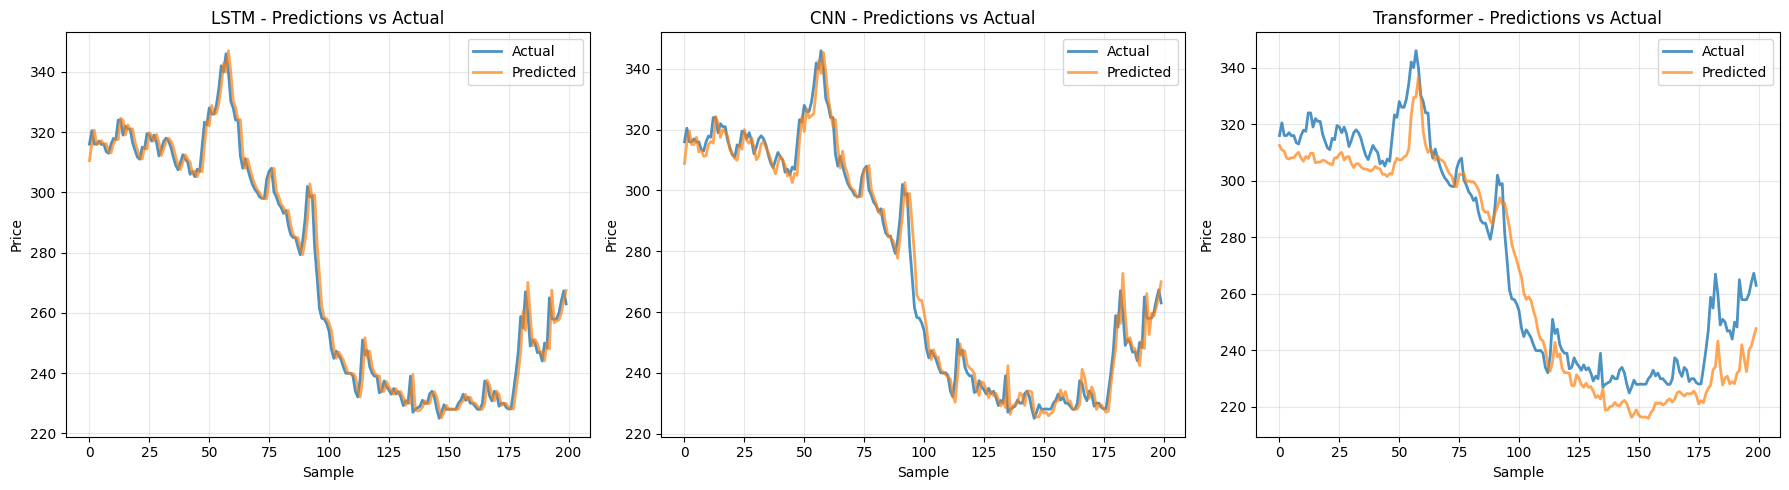

In [13]:
# Plot predictions vs actual for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, pred) in enumerate(predictions_dict.items()):
    axes[idx].plot(y_test[:200], label='Actual', linewidth=2, alpha=0.8)
    axes[idx].plot(pred[:200], label='Predicted', linewidth=2, alpha=0.7)
    axes[idx].set_title(f'{model_name} - Predictions vs Actual')
    axes[idx].set_xlabel('Sample')
    axes[idx].set_ylabel('Price')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

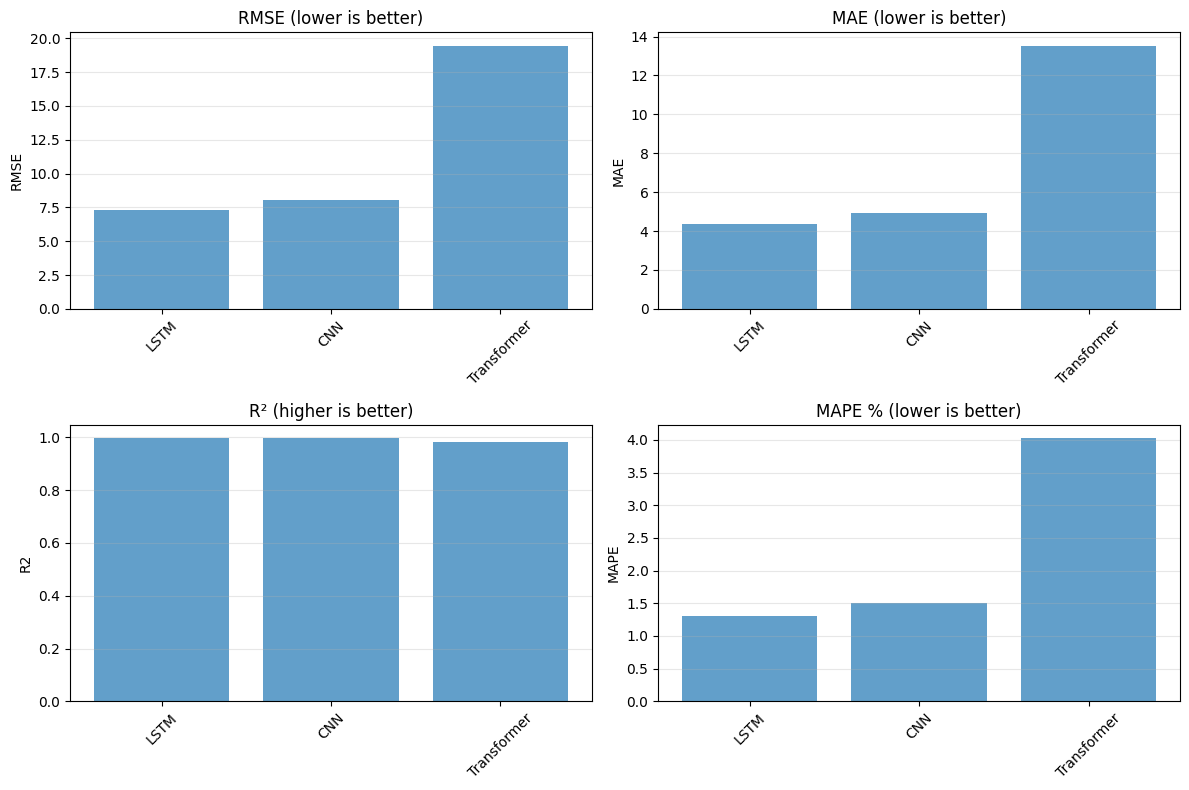

In [14]:
# Plot performance metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

metrics = ['RMSE', 'MAE', 'R2', 'MAPE']
titles = ['RMSE (lower is better)', 'MAE (lower is better)',
          'R² (higher is better)', 'MAPE % (lower is better)']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    row = idx // 2
    col = idx % 2

    axes[row, col].bar(results_df['Model'], results_df[metric], alpha=0.7)
    axes[row, col].set_title(title)
    axes[row, col].set_ylabel(metric)
    axes[row, col].grid(True, alpha=0.3, axis='y')
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

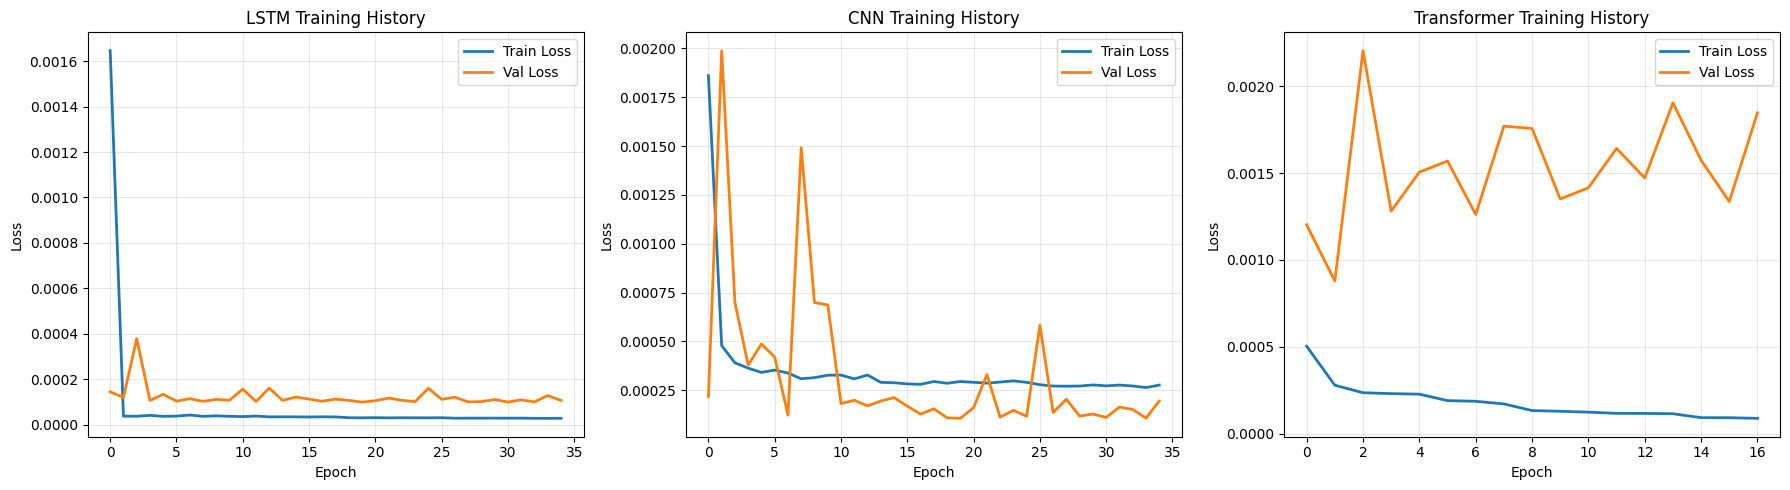

In [15]:
# Plot training history for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, history) in enumerate(histories.items()):
    axes[idx].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[idx].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[idx].set_title(f'{model_name} Training History')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Summary

**Key Findings:**

1. **Feature Engineering**: Using close price and momentum (percentage change) with company embeddings provides a balanced approach between simplicity and expressiveness.

2. **Model Architecture**: Different architectures show varying performance on financial time series data. The results demonstrate the importance of model selection for specific tasks.

3. **Company Embeddings**: Including bank-specific embeddings allows the models to learn unique patterns for each of the 17 commercial banks while maintaining a single global model.

4. **Reproducibility**: All experiments use fixed random seeds (42) to ensure reproducible results across runs.

5. **Evaluation**: Multiple metrics (RMSE, MAE, R², MAPE) provide a comprehensive view of model performance from different perspectives.